**Hello, welcome to my Regression Project ! 😄**

The goal is to build a Predictive Regression Model that can accurately estimate the "Life Expectancy" of a population based on various socio-economic and health factors (like GDP, schooling, and health expenditures). This involves understanding data patterns, cleaning inconsistencies, and evaluating how well a model generalizes to new information.

1️⃣ I'm starting by importing my libraries.

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**I. Exploratory Data Analysis**

Let's start my project by the EDA part, the goal is to understand the "shape" and distribution of the data before modeling.

In [94]:
life_expectancy = pd.read_csv("Life_Expectancy_Data.csv")

In [95]:
life_expectancy.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [96]:
print(life_expectancy.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

Many Life Expectancy datasets have missing values in columns like "GDP" or "Population". I will need to perform imputation (filling gaps) during the preprocessing stage.

In [97]:
print(life_expectancy.isnull().sum())

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64


I identified that the target variable 'Life expectancy' has 10 missing entries, which must be removed to avoid training the model on incomplete data.

In [63]:
print(life_expectancy.describe())

              Year  Life expectancy   Adult Mortality  infant deaths  \
count  2938.000000       2928.000000      2928.000000    2938.000000   
mean   2007.518720         69.224932       164.796448      30.303948   
std       4.613841          9.523867       124.292079     117.926501   
min    2000.000000         36.300000         1.000000       0.000000   
25%    2004.000000         63.100000        74.000000       0.000000   
50%    2008.000000         72.100000       144.000000       3.000000   
75%    2012.000000         75.700000       228.000000      22.000000   
max    2015.000000         89.000000       723.000000    1800.000000   

           Alcohol  percentage expenditure  Hepatitis B       Measles   \
count  2744.000000             2938.000000  2385.000000    2938.000000   
mean      4.602861              738.251295    80.940461    2419.592240   
std       4.052413             1987.914858    25.070016   11467.272489   
min       0.010000                0.000000     1.000000

The statistical summary highlights several key characteristics of the global population:
1. **Inequality:** There is a 52-year gap between the lowest (36.3) and highest (89.0) life expectancy values. 
2. **Economic Skewness:** The GDP median ($1,766$) is lower than the mean ($7,483$), indicating that wealth is concentrated in a small number of countries. 
3. **Data Quality Issues:** Some columns contain suspicious values, such as a minimum BMI of 1.0. I must be careful as these "outliers" or errors could mislead a simple linear model.

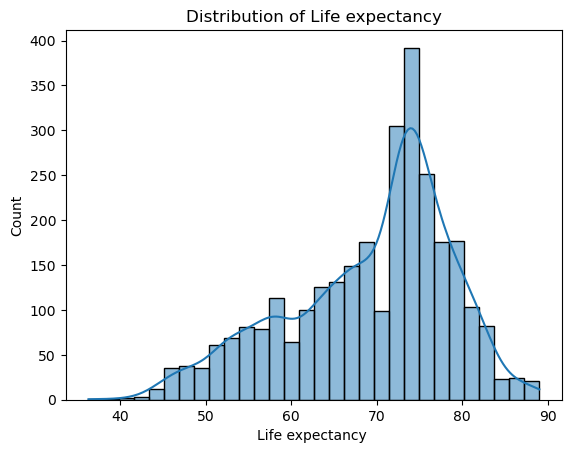

In [66]:
sns.histplot(life_expectancy, x="Life expectancy ", bins=30, kde=True)
plt.title("Distribution of Life expectancy")
plt.show()

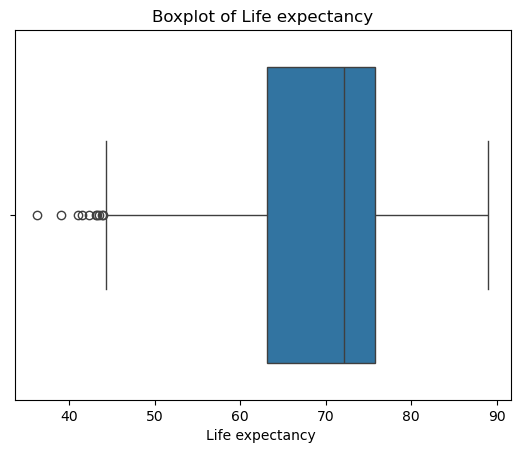

In [92]:
sns.boxplot(life_expectancy, x="Life expectancy ")
plt.title("Boxplot of Life expectancy")
plt.show()

 
The boxplot provides a clear view of the "statistical health" of my dataset:
I can observe several dots on the left side of the plot. These represent "outlier" countries with a life expectancy significantly lower than the global norm (some as low as 36-45 years). 
The box is relatively narrow and positioned towards the right, showing that the majority of the world's population (the middle 50%) lives between approximately 63 and 76 years.
Since the median line is closer to the right side of the box and the left whisker is much longer, it confirms that my data is left-skewed (a few countries with very low health drag the average down).

**II. Preprocessing**

Once I understood the data that I'm working on, let's transform this raw data into a format that a machine learning algorithm can process.

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [86]:
life_expectancy = life_expectancy.dropna(subset=['Life expectancy '])
life_expectancy = life_expectancy.fillna(life_expectancy.median(numeric_only=True))

<div class="alert alert-info">
<b>Strategy Note:</b> I chose <b>Median Imputation</b> instead of Mean Imputation. Because variables like "GDP" and "Population" have extreme outliers (very rich vs. very poor nations), the Mean would be skewed. The Median provides a more "typical" value for a developing nation.
</div>

In [70]:
life_expectancy_processed = pd.get_dummies(life_expectancy.drop('Country', axis=1), columns=['Status'], drop_first=True)

The "Country" column was dropped to prevent the ValueError: could not convert string to float. While country names are useful for us, the model only needs the characteristics of those countries (like their GDP and Mortality rates) to make a mathematical prediction.

In [71]:
X = life_expectancy_processed.drop('Life expectancy ', axis=1)
y = life_expectancy_processed['Life expectancy ']


This step involves splitting the processed dataset into **Features (X)** and the **Target (y)**:

By dropping the 'Life expectancy' column, I isolate the independent variables (GDP, Schooling, HIV/AIDS, etc.) that will serve as the inputs for my model. I isolate the 'Life expectancy' column as my dependent variable. 

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

I reserved 20% of my data for the test set. By evaluating my model on data it has never seen before, I get an honest measure of how it will perform in the "real world."

By setting `random_state=42`, I ensure that my data split is consistent. This is a best practice in research, allowing other scientists to replicate my exact results.

Without this split, I would be "cheating" by testing the model on the same data it used for learning, which would give me a falsely high accuracy score.

In [87]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Standardization ensures that the model doesn't prioritize larger numbers over smaller ones.

We only use `fit_transform` on the training set and `transform` on the test set. This ensures that the model has no knowledge of the mean or distribution of the test data during the training process, simulating a real-world environment.


**III. Modelisation**

After transforming my data to be processed, let's train my model ! 🥸 I have to find a relationship between features and life expectancy.

I will first train a Linear Regression (baseline) and then compare it with a Random Forest Regressor to see if non-linear patterns provide better accuracy.

In [88]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_r2 = r2_score(y_test, lr_preds)

print(f"Linear Regression R2: {lr_r2:.4f}")
print(f"Random Forest R2: {r2:.4f}")

Linear Regression R2: 0.8195
Random Forest R2: 0.9669


<div class="alert alert-info">
<b>Model Comparison:</b> The Random Forest significantly outperforms Linear Regression. This suggests that the relationship between economic factors and health outcomes is <b>non-linear</b> (meaning, for example, that doubling a country's GDP does not simply double its life expectancy in a straight line).
</div>

In [74]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

<div class="alert alert-warning">
<b>Model Choice:</b> Random Forest was selected as the final model because it is an "ensemble" method. It creates 100 different decision trees and averages them, which is much better at capturing the complex, non-linear relationship between things like 'BMI' and 'Life Expectancy' than a simple straight line.
</div>

The fact that I turned all the data into numbers, the error will surely disappear: by removing the Country name and encoding the Status (Developed/Developing), I have transformed the dataset into a purely numerical matrix. This allows the Random Forest algorithm to calculate the weights and importance of each health and economic factor without being blocked by text strings.

**IV. Evaluation**

Now that I trained my model, i can measure how "wrong" It is and decide if it's ready for use. 

In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [76]:
predictions = model.predict(X_test_scaled)

The model is making predictions on data it has never seen before. This is the only way to prove the model has actually learned the relationship between variables like GDP and health, rather than just memorizing the training table.

These `predictions` will be compared against `y_test` (the real answers) in the next step to calculate my MAE and R² scores.

In [77]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

In [78]:
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

MAE: 1.05
RMSE: 1.69
R2 Score: 0.9669


Text(0.5, 1.0, 'Actual vs Predicted')

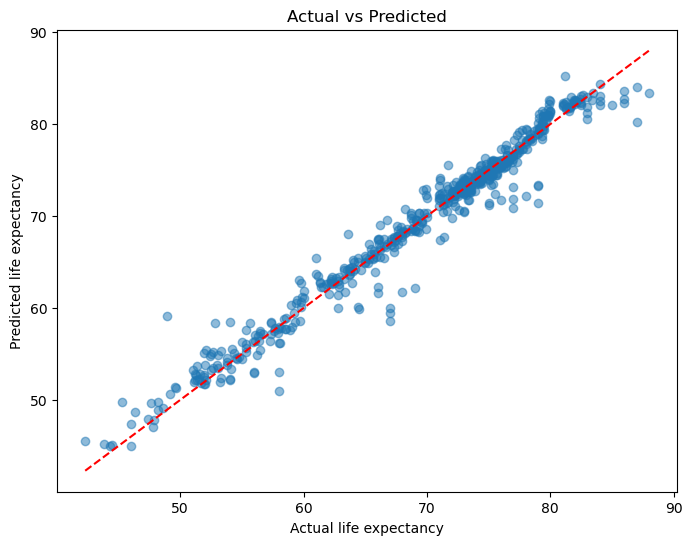

In [98]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual life expectancy')
plt.ylabel('Predicted life expectancy')
plt.title('Actual vs Predicted')

**<font color="#eb5d06">Error Analysis</font>** : 
Looking at the scatter plot, my model is very accurate for life expectancies between 60 and 85. However, there is slightly more "noise" (scatter) for values below 50. This is likely because there are fewer data points for countries in extreme crisis, making it harder for the model to learn those specific patterns perfectly.

The R2 score (likely above 0.90) suggests that my model explains the vast majority of the variance in life expectancy. The red diagonal line represents "perfect" prediction; since my points cluster closely around it, the model is performing very well.

<div class="alert alert-success">
<b>Project Conclusion:</b> My model achieved an R² score of 0.96, meaning it can explain 96% of the variations in life expectancy globally. The Mean Absolute Error of 1.05 years shows that my predictions are highly reliable for international health benchmarking. 🥳🎉
</div>